In [5]:
!pip install sumy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 20.3 MB/s eta 0:00:00
  Created wheel for breadability: filename=breadability-0.1.20-py2.py3-none-any.whl size=21695 sha256=17b9654683259caabd51082282103e013c36443ee96accd08dad5e0f5e9f96ab
  Stored in directory: /root/.cache/pip/wheels/32/99/64/59305409cacd03aa03e7bddf31a9db34b1fa7033bd41972662
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=703c345942809d897ecc982d414854cf94bcd765c653e5bd55874e3ba59896f4
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built breadability docopt


In [6]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

text = """Hello everyone, my name is Bunny.
I am passionate about Machine Learning, Data Science, and Artificial Intelligence
I have learned Python, Data Analysis, Data Visualization, and several Machine Learning algorithms
Currently, I am exploring NLP and Deep Learning using TensorFlow and Keras
I am always eager to learn new technologies and improve my problem-solving skills"""

parser = PlaintextParser.from_string(text, Tokenizer('english'))
summarizer = LsaSummarizer()
summary = summarizer(parser.document, 2) # pick top 2 sentences
for sentence in summary:
  print(sentence)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Hello everyone, my name is Bunny.
I am passionate about Machine Learning, Data Science, and Artificial Intelligence I have learned Python, Data Analysis, Data Visualization, and several Machine Learning algorithms Currently, I am exploring NLP and Deep Learning using TensorFlow and Keras I am always eager to learn new technologies and improve my problem-solving skills


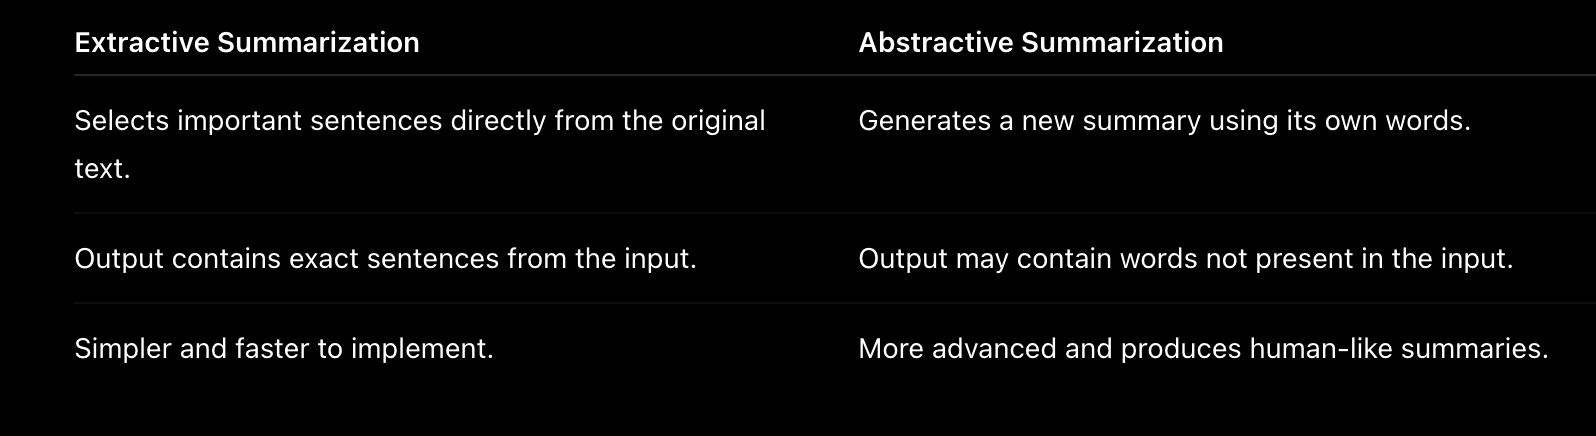

In [7]:
!pip install transformers torch

In [8]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

article = """my name is Bunny.
I am passionate about Machine Learning, Data Science, and Artificial Intelligence.
I have learned Python, Data Analysis, Data Visualization, and several Machine Learning algorithms.
Currently, I am exploring NLP and Deep Learning using TensorFlow and Keras.
I am always eager to learn new technologies and improve my problem-solving skills."""

tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
model = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")

inputs = tokenizer(article, return_tensors="pt", truncation=True, max_length=1024)
summary_ids = model.generate(inputs["input_ids"], num_beams=4, max_length=60, min_length=20, early_stopping=True)

print(tokenizer.decode(summary_ids[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

 Bunny is passionate about Machine Learning, Data Science, and Artificial Intelligence . Currently exploring NLP and Deep Learning using TensorFlow and Keras .


In [9]:
!pip install spacy

In [10]:
import spacy
nlp = spacy.load('en_core_web_sm')
text = 'bunny went for a Secret Date with the special person from nen cheppani college but not ksrm Yesterday at NakNachina Restaurent'
doc = nlp(text)
for ent in doc.ents:
  print(ent.text, '->', ent.label_)

a Secret Date -> WORK_OF_ART
Yesterday -> DATE
NakNachina Restaurent -> ORG


In [11]:
from spacy import displacy
displacy.render(doc, style='ent', jupyter=True)
html = displacy.render(doc, style='ent', page=True, jupyter=False)
with open('entities.html', 'w') as f:
  f.write(html)

In [12]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-hi")
model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-hi")

text_to_translate = 'bunny loves to eat in hostel for entire life'

inputs = tokenizer(text_to_translate, return_tensors="pt")

translated_ids = model.generate(**inputs)
translated_text = tokenizer.decode(translated_ids[0], skip_special_tokens=True)
print(translated_text)

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

पूरे जीवन के लिए होस्टेल में खाना पसंद करता है


In [13]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = 'facebook/nllb-200-distilled-600M'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

faq = {
'hours': 'We are open from 9 AM to 6 PM, Monday to Saturday.',
'returns': 'You can return any item within 30 days with a receipt.',
'shipping':'Standard shipping takes 3-5 business days.',
}

def answer_faq(question_key, target_lang_code):
  english_answer = faq.get(question_key, 'Sorry, I do not have that answer.')
  tokenizer.src_lang = 'eng_Latn'
  inputs = tokenizer(english_answer, return_tensors="pt")
  translated_ids = model.generate(**inputs, forced_bos_token_id=tokenizer.convert_tokens_to_ids(target_lang_code))
  translated_text = tokenizer.decode(translated_ids[0], skip_special_tokens=True)
  return translated_text

print(answer_faq('hello', 'tel_Telu'))


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

క్షమించండి, నాకు ఆ సమాధానం లేదు.


In [14]:
articles = [
"""Apple unveiled its newest iPhone at an event in Cupertino on
Tuesday.
CEO Tim Cook said the device features a faster chip and improved
camera.
The phone will be available in stores starting next month, the company
said, with prices starting at $999.""",
"""The World Health Organization announced new guidelines on Monday
aimed at reducing sugar consumption worldwide. Officials in Geneva
said
the changes could prevent millions of cases of diabetes over the next
decade if adopted by national governments.""",
"""Tesla reported record deliveries for the third quarter, beating
analyst expectations. The Texas-based company said demand remained
strong in China and Europe despite increased competition from
traditional automakers entering the EV market.""",
"""NASA's Perseverance rover discovered new evidence of ancient
water activity on Mars, according to a paper published this week.
Scientists at the Jet Propulsion Laboratory said the findings
strengthen the case that the planet once had a wetter climate.""",
"""Manchester United announced the signing of a new midfielder
from Barcelona for a reported fee of 80 million euros. The 24-year-old
player will join the club ahead of the new season starting in
August.""",
]

In [15]:
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
nlp = spacy.load('en_core_web_sm')
summarizer_tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
summarizer_model = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

In [16]:
def digest_article(text):
    # Summarise (abstractive, short)
    inputs = summarizer_tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    summary_ids = summarizer_model.generate(inputs["input_ids"], num_beams=4, max_length=40, min_length=10, do_sample=False, early_stopping=True)
    summary_text = summarizer_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    # Extract entities
    doc = nlp(text)
    entities = {}

    for ent in doc.ents:
        entities.setdefault(ent.label_, set()).add(ent.text)

    return summary_text, entities


for i, article in enumerate(articles, 1):
    summary, entities = digest_article(article)

    print(f"--- Article {i} ---")
    print("Summary :", summary)
    print("Entities:")

    for label, names in entities.items():
        print(f"  {label}: {', '.join(names)}")

    print()

--- Article 1 ---
Summary :  CEO Tim Cook said the device features a faster chip and improved camera . The phone will be available in stores starting next month, with prices starting at $999 .
Entities:
  ORG: Apple
  GPE: Cupertino
  DATE: Tuesday, next month
  PERSON: Tim Cook
  MONEY: 999

--- Article 2 ---
Summary :  The World Health Organization announced new guidelines aimed at reducing sugar consumption worldwide . Officials in Geneva said the changes could prevent millions of cases of diabetes over the next decade .
Entities:
  ORG: The World Health Organization
  DATE: Monday, the next
decade
  GPE: Geneva
  CARDINAL: millions

--- Article 3 ---
Summary :  Tesla reported record deliveries for the third quarter, beating analyst expectations . The Texas-based company said demand remained strong in China and Europe .
Entities:
  DATE: the third quarter
  GPE: Texas, China
  LOC: Europe
  ORG: EV

--- Article 4 ---
Summary :  NASA's Perseverance rover discovered new evidence of an